This step evaluates the temporal availability of the historical and recent detector datasets for the selected intersections. Since the older JSON files and the newer JSON files have slightly different internal structures, a unified parser is used to extract the common traffic count information. The goal is to identify full, partial, and empty days and to determine which periods are suitable for subsequent approach-based aggregation and LSTM modeling.
****

***
**LSA10-specific output folder + usable-day extraction**
***

In [1]:
from pathlib import Path
import pandas as pd

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
DAY_SUMMARY_CSV = BASE_DIR / "historical_availability_analysis" / "historical_recent_day_summary.csv"

LSA_NAME = "LD-LSA10"
OUT_DIR = BASE_DIR / "LSA10"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_USABLE_DAYS_CSV = OUT_DIR / "LSA10_usable_days.csv"
OUT_DAY_STATUS_CSV = OUT_DIR / "LSA10_day_status_summary.csv"

# ============================================================
# LOAD
# ============================================================

day_summary = pd.read_csv(DAY_SUMMARY_CSV)

# ============================================================
# FILTER FOR LSA16
# ============================================================

lsa_day_summary = day_summary[day_summary["lsa"] == LSA_NAME].copy()

usable_days = lsa_day_summary[
    lsa_day_summary["model_usability"].isin(["usable", "usable_partial"])
].copy()

usable_days = usable_days.sort_values(["date_str", "source_period"]).reset_index(drop=True)

# save
lsa_day_summary.to_csv(OUT_DAY_STATUS_CSV, index=False, encoding="utf-8-sig")
usable_days.to_csv(OUT_USABLE_DAYS_CSV, index=False, encoding="utf-8-sig")

print("Saved:")
print(OUT_DAY_STATUS_CSV)
print(OUT_USABLE_DAYS_CSV)

print("\nUsable day counts:")
print(usable_days.groupby(["source_period", "model_usability"]).size())

print("\nFirst usable days:")
print(usable_days[["date_str", "source_period", "day_status", "model_usability"]].head(20))

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10\LSA10_day_status_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10\LSA10_usable_days.csv

Usable day counts:
source_period  model_usability
historical     usable             126
               usable_partial      10
recent         usable              13
               usable_partial      34
dtype: int64

First usable days:
      date_str source_period   day_status model_usability
0   2025-01-31    historical  partial_day  usable_partial
1   2025-02-01    historical     full_day          usable
2   2025-02-02    historical     full_day          usable
3   2025-02-03    historical     full_day          usable
4   2025-02-04    historical     full_day          usable
5   2025-02-05    historical     full_day          usable
6   2025-02-06    historical     full_day          usable
7   2025-02-07    historical     full_day          usable
8   2025-02-08    historical     full_day          usable
9   2025-0

**Approach-based count aggregation for LSA16**

This step combines the historical and recent detector JSON files for LSA16 and aggregates the selected detector counts to the approach level. The result is a continuous 15-minute approach-based traffic count dataset for the west, south, east, and north inflow directions of LSA16, which forms the basis for intersection-specific forecasting.

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

HIST_DIR = BASE_DIR / "Six_Months_Data" / "LD-LSA10"
RECENT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA10")

OUT_DIR = BASE_DIR / "LSA10"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_RAW_CSV = OUT_DIR / "LSA10_raw_long.csv"
OUT_APPROACH_CSV = OUT_DIR / "LSA10_approach_counts_15min.csv"
OUT_MAPPING_CSV = OUT_DIR / "LSA10_mapping_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"

# ============================================================
# LSA10 MAPPING
# ============================================================

LSA10_MAPPING = {
    "street_names": {
        "west": "Schloßstraße",
        "south": "Bismarckstraße",
        "east": "Marienring",
        "north_west": "Karl-Sauer-Straße",
        "north_east": "Südring",
    },
    "inflow": {
        "west": [1],
        "south": [31],
        "east": [3, 4],
        "north_west": [29],
        "north_east": [27, 26],
    },
    "outflow": {}
}

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ FILES
# ============================================================

all_files = []
if HIST_DIR.exists():
    all_files += [(p, "historical") for p in sorted(HIST_DIR.glob("*.json"))]
if RECENT_DIR.exists():
    all_files += [(p, "recent") for p in sorted(RECENT_DIR.glob("*.json"))]

rows = []

for path, source_period in all_files:
    try:
        data = parse_json_file(path)
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        continue

    timeframes = data.get("timeFrames", [])

    for tf in timeframes:
        ts_utc = tf.get("timestamp")
        detectors = tf.get("detectors", [])

        if len(detectors) == 0:
            continue

        for det in detectors:
            rows.append({
                "source_period": source_period,
                "source_file": path.name,
                "date_from_name": extract_date_from_filename(path),
                "timestamp_utc": ts_utc,
                "detector_id": safe_get(det, ["id"]),
                "count": safe_get(det, ["reading", "count", "value"]),
            })

raw_df = pd.DataFrame(rows)

# ============================================================
# CLEAN / TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")

raw_df = raw_df.dropna(subset=["timestamp_berlin", "detector_id", "count"]).copy()
raw_df = raw_df.sort_values("timestamp_berlin").reset_index(drop=True)

raw_df.to_csv(OUT_RAW_CSV, index=False, encoding="utf-8-sig")

print("Saved raw long table:")
print(OUT_RAW_CSV)
print("Raw shape:", raw_df.shape)

# ============================================================
# SAVE MAPPING SUMMARY
# ============================================================

mapping_rows = []
for approach, dets in LSA10_MAPPING["inflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA10",
        "approach": approach,
        "street_name": LSA10_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "inflow"
    })

for approach, dets in LSA10_MAPPING["outflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA10",
        "approach": approach,
        "street_name": "",
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "outflow"
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("\nSaved mapping summary:")
print(OUT_MAPPING_CSV)

# ============================================================
# AGGREGATE INFLOW COUNTS
# ============================================================

approach_tables = []

for approach, dets in LSA10_MAPPING["inflow"].items():
    temp = raw_df[raw_df["detector_id"].isin(dets)].copy()

    agg = (
        temp.groupby("timestamp_berlin", as_index=False)
        .agg(count=("count", "sum"))
    )

    agg = agg.rename(columns={"count": f"LSA10_{approach}_count"})
    approach_tables.append(agg)

# merge all approaches
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], utc=True, errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved LSA10 approach dataset:")
print(OUT_APPROACH_CSV)
print("Approach shape:", approach_df.shape)
print("\nPreview:")
print(approach_df.head())

Saved raw long table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10\LSA10_raw_long.csv
Raw shape: (709054, 7)

Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10\LSA10_mapping_summary.csv

Saved LSA10 approach dataset:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10\LSA10_approach_counts_15min.csv
Approach shape: (17294, 10)

Preview:
           timestamp_berlin  LSA10_west_count  LSA10_south_count  \
0 2025-01-31 09:45:00+00:00                45                 26   
1 2025-01-31 10:00:00+00:00                43                 28   
2 2025-01-31 10:15:00+00:00                26                 23   
3 2025-01-31 10:30:00+00:00                61                 13   
4 2025-01-31 10:45:00+00:00                44                 22   

   LSA10_east_count  LSA10_north_west_count  LSA10_north_east_count  \
0                59                       5                      33   
1                84                       9                 

 *** 
### **Exploratory analysis of the LSA10 approach-based dataset**

This step checks the completeness and temporal structure of the LSA10 approach-level count dataset and visualizes the main traffic patterns before forecasting.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10")
APPROACH_CSV = BASE_DIR / "LSA10_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# safer parsing for mixed +01:00 / +02:00 timestamps
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")

# convert to Europe/Berlin local time and remove timezone for easier plotting/grouping
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA10_west_count",
    "LSA10_south_count",
    "LSA10_east_count",
    "LSA10_north_west_count",
    "LSA10_north_east_count",
]

print("Shape:", df.shape)

print("\nMissing values per count column:")
print(df[count_cols].isna().sum())

print("\nTime range:")
print(df["timestamp_berlin"].min(), "to", df["timestamp_berlin"].max())

# time gap check
time_diff = df["timestamp_berlin"].diff().value_counts().sort_index()
print("\nMost common time differences:")
print(time_diff.head(10))

print("\nBasic statistics:")
print(df[count_cols].describe())

Shape: (17294, 10)

Missing values per count column:
LSA10_west_count          0
LSA10_south_count         0
LSA10_east_count          0
LSA10_north_west_count    0
LSA10_north_east_count    0
dtype: int64

Time range:
2025-01-31 10:45:00 to 2026-04-16 08:45:00

Most common time differences:
timestamp_berlin
0 days 00:15:00      17250
0 days 00:30:00         35
0 days 00:45:00          3
0 days 01:15:00          2
0 days 07:30:00          1
9 days 10:15:00          1
249 days 13:30:00        1
Name: count, dtype: int64

Basic statistics:
       LSA10_west_count  LSA10_south_count  LSA10_east_count  \
count      17294.000000       17294.000000      17294.000000   
mean          39.412918           8.456112         64.585637   
std           28.021161           7.725163         45.792538   
min            0.000000           0.000000          0.000000   
25%           13.000000           2.000000         21.000000   
50%           39.000000           7.000000         69.000000   
75%     

**Interpretation of the LSA16 exploratory analysis**

The exploratory analysis shows that the LSA16 approach-level dataset is largely complete and well structured for forecasting purposes. All four aggregated inflow count series are available without missing values, and the temporal resolution is predominantly consistent at 15-minute intervals. The dataset covers the period from January 2025 to April 2026 and contains 20,688 approach-based observations. Descriptive statistics indicate that the east and south approaches carry the highest average traffic volumes, while the north approach shows the lowest average demand but includes at least one unusually high peak, suggesting a potential outlier. The time-difference analysis further reveals that most observations are consecutive at 15-minute spacing, although a limited number of short gaps and one major gap between the historical and recent datasets are present. This confirms that LSA16 is highly suitable for intersection-specific forecasting, while also indicating that sequence generation should avoid spanning large discontinuities in the time series.
## I will train the model on past observed traffic patterns and evaluate whether it can generalize to a later unseen period.

Because the LSA16 dataset consists of a historical block and a separate recent block with a large temporal gap in between, the forecasting workflow is defined blockwise rather than treating the entire series as one continuous sequence. The historical data are used for model training, while the recent data are reserved for validation and testing. This avoids constructing invalid sequences across the long interruption between the two periods and provides a realistic evaluation of how well the model generalizes from past traffic patterns to a later unseen time period.

**1)Blockwise split for LSA16 forecasting**
Since the LSA16 dataset contains a historical block and a separate recent block, the modeling workflow is defined blockwise. The historical data are used for training, while the recent data are divided into validation and test subsets. This avoids constructing sequences across the long temporal gap between the two periods.

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10")
APPROACH_CSV = BASE_DIR / "LSA10_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# Safe timestamp parsing
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA10_west_count",
    "LSA10_south_count",
    "LSA10_east_count",
    "LSA10_north_west_count",
    "LSA10_north_east_count",
]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# BLOCKWISE SPLIT
# ============================================================

historical_df = data[data["timestamp_berlin"] < "2026-01-01"].copy()
recent_df = data[data["timestamp_berlin"] >= "2026-01-01"].copy()

print("Historical shape:", historical_df.shape)
print("Recent shape:", recent_df.shape)

print("\nHistorical range:")
print(historical_df["timestamp_berlin"].min(), "to", historical_df["timestamp_berlin"].max())

print("\nRecent range:")
print(recent_df["timestamp_berlin"].min(), "to", recent_df["timestamp_berlin"].max())

Historical shape: (12886, 6)
Recent shape: (4408, 6)

Historical range:
2025-01-31 10:45:00 to 2025-06-24 11:45:00

Recent range:
2026-03-01 01:15:00 to 2026-04-16 08:45:00


**2) Validation-test split within the recent period**
The recent data are split chronologically into validation and test subsets in order to preserve the temporal order of observations.

In [5]:
# ============================================================
# SPLIT RECENT INTO VALIDATION / TEST
# ============================================================

n_recent = len(recent_df)
val_end = int(n_recent * 0.50)

val_df = recent_df.iloc[:val_end].copy()
test_df = recent_df.iloc[val_end:].copy()
train_df = historical_df.copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())

print("\nValidation range:")
print(val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())

print("\nTest range:")
print(test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Train: (12886, 6)
Validation: (2204, 6)
Test: (2204, 6)

Train range:
2025-01-31 10:45:00 to 2025-06-24 11:45:00

Validation range:
2026-03-01 01:15:00 to 2026-03-24 05:45:00

Test range:
2026-03-24 06:00:00 to 2026-04-16 08:45:00


**3)Sequence generation for LSA16**
The approach-based traffic count series are transformed into sequential samples for one-step-ahead forecasting. The previous four 15-minute observations are used to predict the next 15-minute traffic state.


In [6]:
# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZON = 1

# ============================================================
# SCALE USING TRAIN ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled = scaler.transform(val_df[count_cols])
test_scaled = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

X_train: (12882, 4, 5) y_train: (12882, 5)
X_val:   (2200, 4, 5) y_val: (2200, 5)
X_test:  (2200, 4, 5) y_test: (2200, 5)


**4) Naive baseline for LSA16**
A persistence-based baseline is used as a benchmark. It predicts that the next traffic state is equal to the most recent observed state.

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Naive prediction = last observed step in the input sequence
y_pred_naive_scaled = X_test[:, -1, :]

# Back to original counts
y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_mse_naive = mean_squared_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = np.sqrt(overall_mse_naive)

print("LSA10 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

LSA10 Naive baseline:
MAE : 5.368
MSE : 75.307
RMSE: 8.678


**LSTM model for LSA10**
An LSTM model is trained to predict the next 15-minute traffic counts for the four inflow approaches of LSA16.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,245 (71.27 KB)

 Trainable params: 18,245 (71.27 KB)

 Non-trainable params: 0 (0.00 B)

**6) Training of the LSTM model**
The model is trained on the historical data and validated on the early recent period. Early stopping is used to reduce overfitting.


In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0141 - val_loss: 0.0047
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0050 - val_loss: 0.0043
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0048 - val_loss: 0.0043
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 8/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 9/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 10/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 11/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 12/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

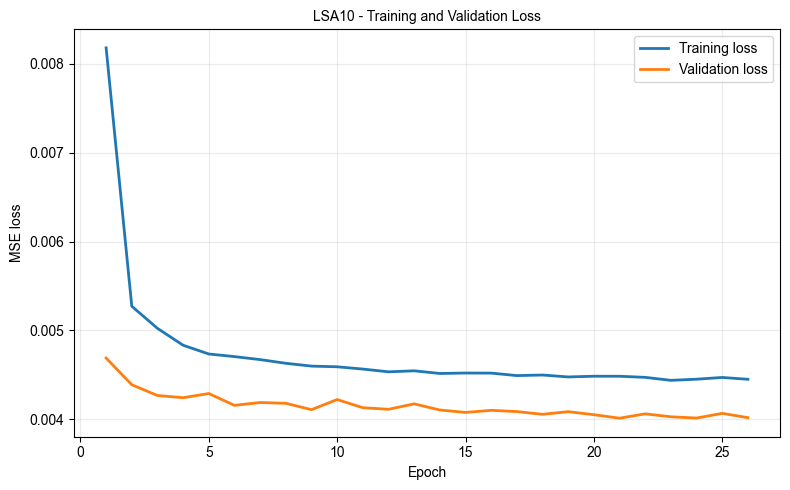

   epoch  train_loss  val_loss
0      1    0.008178  0.004690
1      2    0.005272  0.004390
2      3    0.005024  0.004269
3      4    0.004834  0.004244
4      5    0.004736  0.004291


In [11]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

loss_df = pd.DataFrame({
    "epoch": range(1, len(history.history["loss"]) + 1),
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"]
})

plt.figure(figsize=(8, 5))
plt.plot(loss_df["epoch"], loss_df["train_loss"], label="Training loss", linewidth=2)
plt.plot(loss_df["epoch"], loss_df["val_loss"], label="Validation loss", linewidth=2)
plt.title("LSA10 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(loss_df.head())

**The validation loss remains slightly below the training loss during the LSTM training process. This behavior is not problematic and can be explained by the use of dropout regularization, which is active only during training and makes the training task more difficult. During validation, dropout is inactive, so the model can use its full capacity. In addition, the validation period may contain more regular traffic patterns than the training period. Since both losses decrease and remain close to each other, the training process can be considered stable, with no clear indication of severe overfitting.**

The training and validation loss curves for LSA10 show a stable and well-behaved learning process. Both losses decrease rapidly in the initial epochs and converge to low values, indicating effective learning of temporal traffic patterns. Notably, the validation loss remains slightly below the training loss throughout the training process. This behavior can be attributed to the use of dropout regularization during training, which increases training loss, while being inactive during validation. Additionally, the validation dataset (recent period) may exhibit more regular traffic patterns compared to the historical training data, resulting in lower prediction error. Overall, the absence of divergence between training and validation loss indicates that the model generalizes well and does not suffer from overfitting.

**7)Evaluation of the LSA10 LSTM model**
The trained LSTM model is evaluated on the unseen recent test period and compared with the naive baseline.

In [13]:
y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_mse_lstm = mean_squared_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = np.sqrt(overall_mse_lstm)

print("LSA10 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

print("\nLSA10 LSTM:")
print("MAE :", round(overall_mae_lstm, 3))
print("MSE :", round(overall_mse_lstm, 3))
print("RMSE:", round(overall_rmse_lstm, 3))

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
LSA10 Naive baseline:
MAE : 5.368
MSE : 75.307
RMSE: 8.678

LSA10 LSTM:
MAE : 4.639
MSE : 56.524
RMSE: 7.518


   model       MAE        MSE      RMSE
0  Naive  5.368455  75.306636  8.677940
1   LSTM  4.638547  56.524260  7.518262


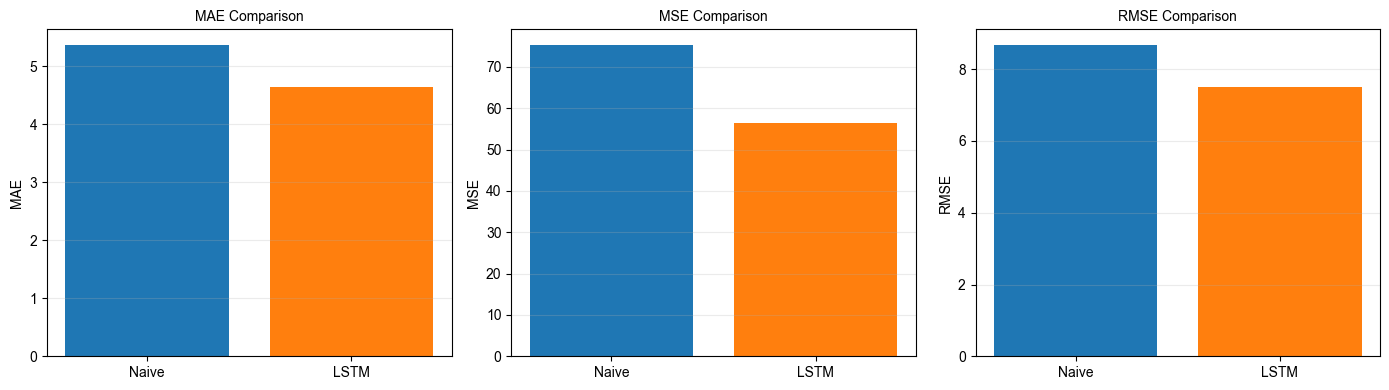

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

metrics_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive, overall_mae_lstm],
    "MSE": [overall_mse_naive, overall_mse_lstm],
    "RMSE": [overall_rmse_naive, overall_rmse_lstm]
})

print(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(metrics_df["model"], metrics_df["MAE"], color=["tab:blue", "tab:orange"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(metrics_df["model"], metrics_df["MSE"], color=["tab:blue", "tab:orange"])
axes[1].set_title("MSE Comparison")
axes[1].set_ylabel("MSE")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(metrics_df["model"], metrics_df["RMSE"], color=["tab:blue", "tab:orange"])
axes[2].set_title("RMSE Comparison")
axes[2].set_ylabel("RMSE")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

per-approach MAE and RMSE 

     approach  naive_MAE  lstm_MAE   naive_MSE    lstm_MSE  naive_RMSE  \
0        west   7.781364  6.914089  126.502273   95.421544   11.247323   
1       south   3.001818  2.550314   19.591818   13.508962    4.426265   
2        east  10.065909  8.804778  193.124091  150.061900   13.896909   
3  north_west   2.144091  1.832315   10.724091    7.148156    3.274766   
4  north_east   3.849091  3.091238   26.590909   16.480741    5.156637   

   lstm_RMSE  
0   9.768395  
1   3.675454  
2  12.249975  
3   2.673604  
4   4.059648  


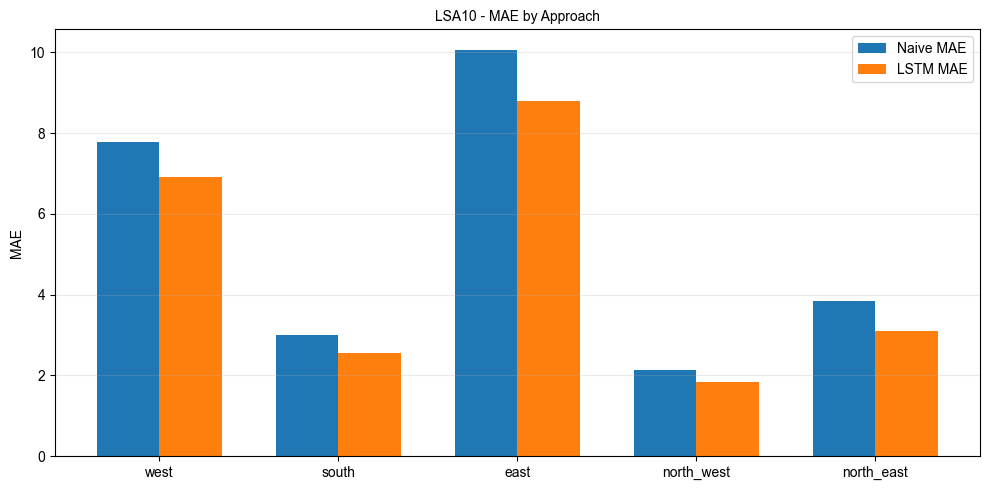

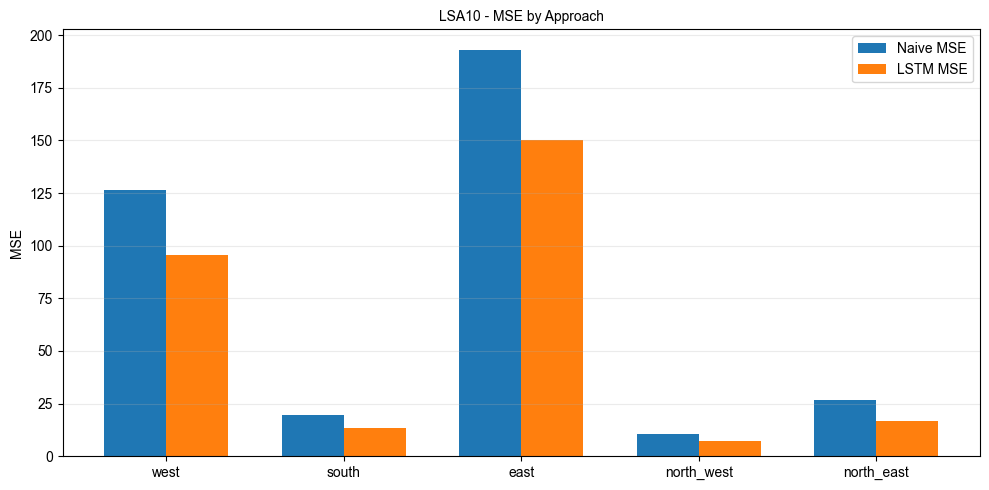

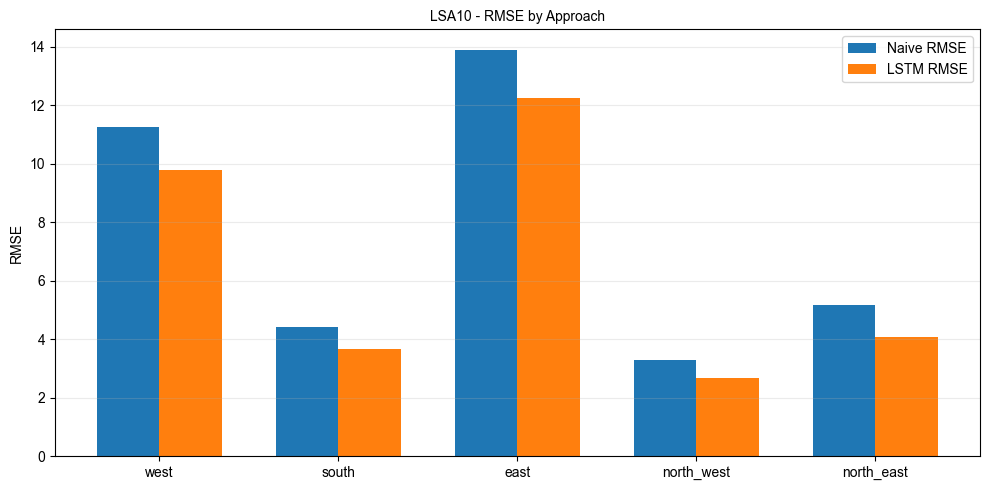

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

rows = []

for i, feature in enumerate(count_cols):
    approach_name = feature.replace("LSA10_", "").replace("_count", "")

    naive_mae = mean_absolute_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mae = mean_absolute_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_mse = mean_squared_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mse = mean_squared_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_rmse = np.sqrt(naive_mse)
    lstm_rmse = np.sqrt(lstm_mse)

    rows.append({
        "approach": approach_name,
        "naive_MAE": naive_mae,
        "lstm_MAE": lstm_mae,
        "naive_MSE": naive_mse,
        "lstm_MSE": lstm_mse,
        "naive_RMSE": naive_rmse,
        "lstm_RMSE": lstm_rmse,
    })

per_feature_df = pd.DataFrame(rows)
print(per_feature_df)

x = np.arange(len(per_feature_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, per_feature_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA10 - MAE by Approach")
plt.ylabel("MAE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_MSE"], width, label="Naive MSE")
plt.bar(x + width/2, per_feature_df["lstm_MSE"], width, label="LSTM MSE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA10 - MSE by Approach")
plt.ylabel("MSE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, per_feature_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA10 - RMSE by Approach")
plt.ylabel("RMSE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

since east heavily loaded, more error lies there

**8)Visualization of actual, naive, and LSTM predictions for LSA10**
This step compares the observed traffic counts with the naive baseline and LSTM forecasts for the four LSA10 inflow approaches.

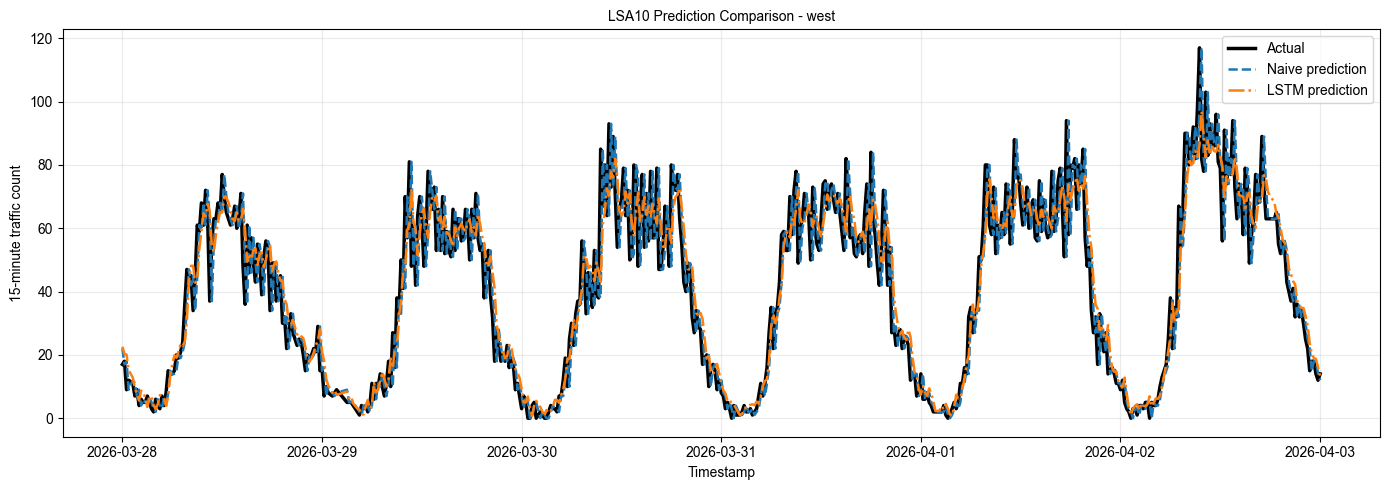

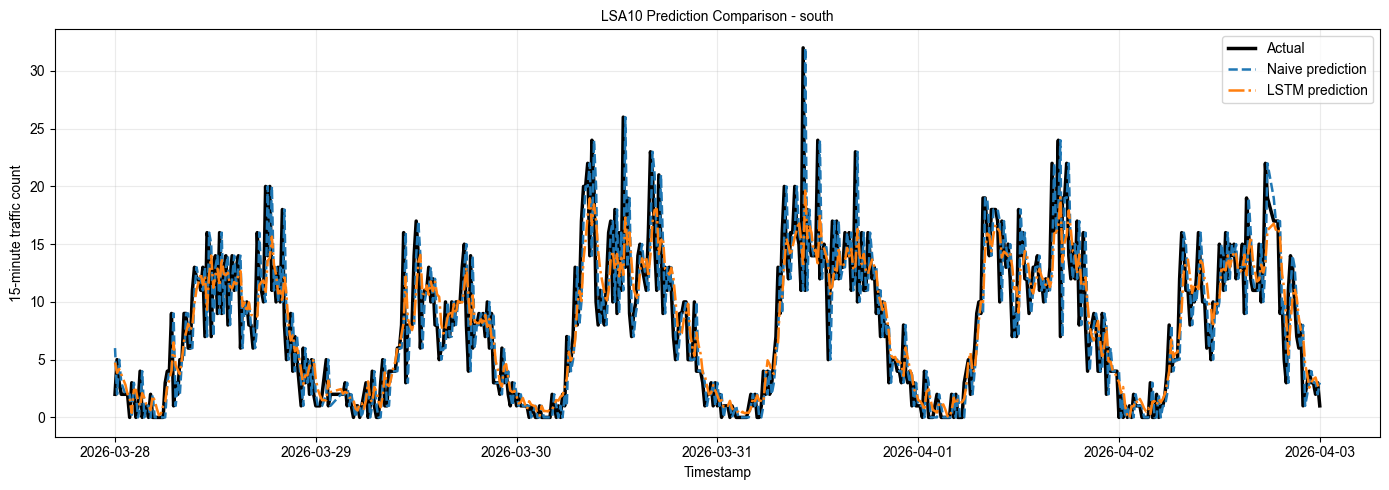

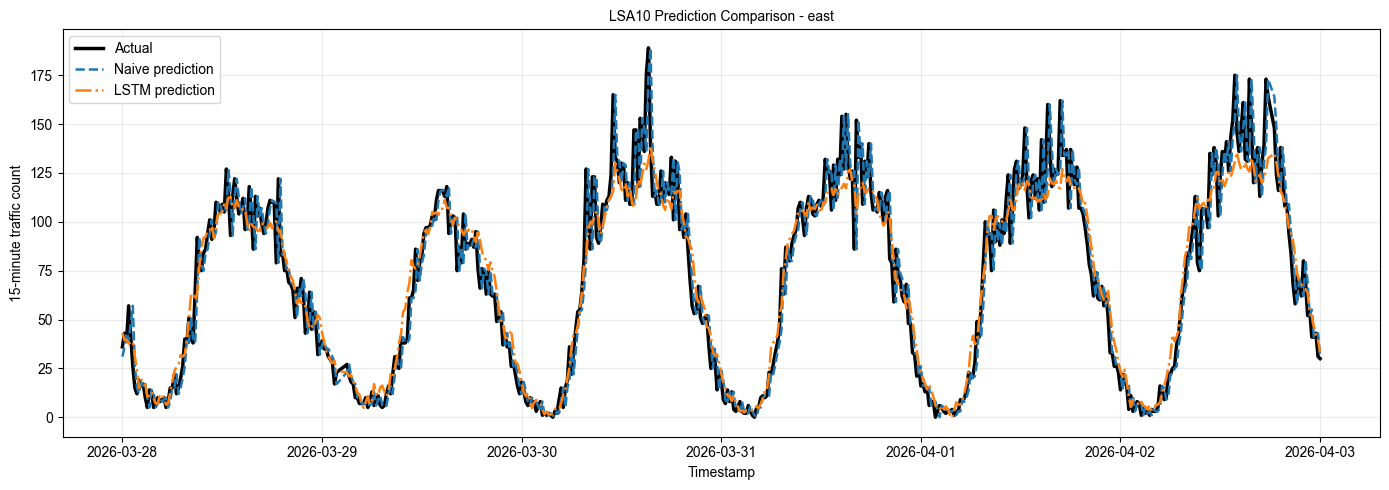

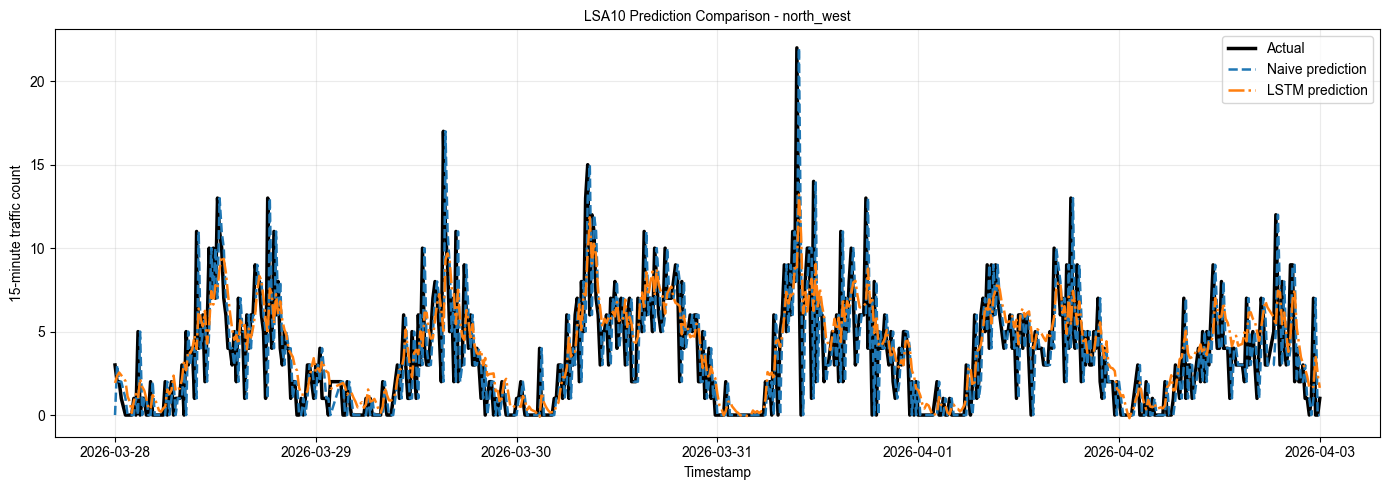

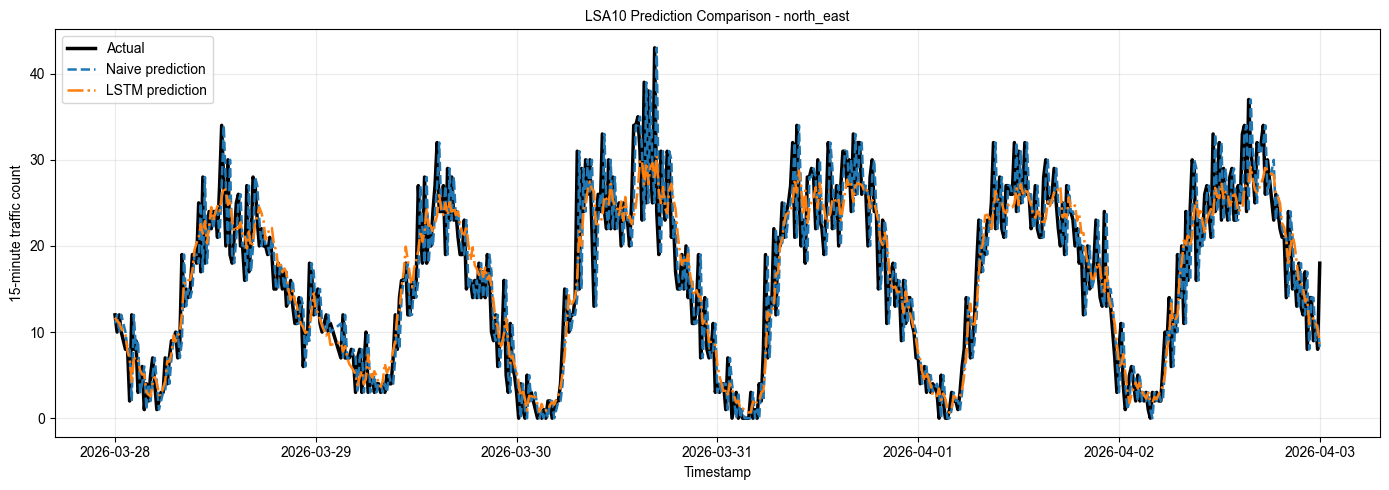

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

plot_features = count_cols.copy()

# choose a shorter visible window inside the test period
# examples:
# window_start = "2026-03-28"
# window_end   = "2026-04-02"

window_start = "2026-03-28"
window_end   = "2026-04-03"

test_timestamps = test_df["timestamp_berlin"].iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)

mask = (test_timestamps >= window_start) & (test_timestamps <= window_end)

plot_timestamps = test_timestamps[mask]

for feature in plot_features:
    idx = count_cols.index(feature)

    actual = y_test_actual[:, idx][mask]
    naive = y_pred_naive_actual[:, idx][mask]
    lstm = y_pred_lstm_actual[:, idx][mask]

    plt.figure(figsize=(14, 5))

    plt.plot(plot_timestamps, actual, label="Actual", linewidth=2.5, color="black")
    plt.plot(plot_timestamps, naive, label="Naive prediction", linestyle="--", linewidth=1.8)
    plt.plot(plot_timestamps, lstm, label="LSTM prediction", linestyle="-.", linewidth=1.8)

    plt.title(f"LSA10 Prediction Comparison - {feature.replace('LSA10_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Data Availability**

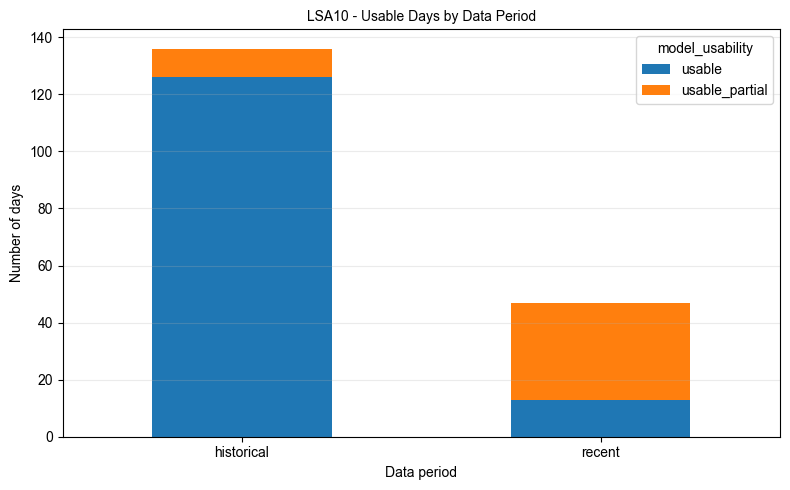

model_usability  usable  usable_partial
source_period                          
historical          126              10
recent               13              34


In [15]:
from pathlib import Path
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA10")
USABLE_DAYS_CSV = BASE_DIR / "LSA10_usable_days.csv"

# ============================================================
# LOAD
# ============================================================

usable_days = pd.read_csv(USABLE_DAYS_CSV)

summary = (
    usable_days.groupby(["source_period", "model_usability"])
    .size()
    .unstack(fill_value=0)
)

# keep clean order
for col in ["usable", "usable_partial"]:
    if col not in summary.columns:
        summary[col] = 0

summary = summary[["usable", "usable_partial"]]

ax = summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("LSA10 - Usable Days by Data Period")
ax.set_xlabel("Data period")
ax.set_ylabel("Number of days")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(summary)

**Epoch**

An epoch means one full pass through the training dataset.
If i train for 30 epochs, the model sees the full training data 30 times and updates its weights each time.

**Dropout**

Dropout is a regularization method. During training, it randomly ignores a fraction of neurons, here 20%, so that the model does not rely too heavily on specific patterns. This helps reduce overfitting and improves generalization to unseen data.

**Training loss**

The training loss is the model’s error on the training set during learning. It shows how well the model fits the data it is trained on.

**Validation loss**

The validation loss is the model’s error on unseen validation data after each epoch. It is important because it shows whether the model is learning patterns that generalize, rather than just memorizing the training data.

**MAE**

MAE means Mean Absolute Error. It tells, on average, how many vehicles the prediction is off by, without squaring the errors.

**RMSE**

RMSE means Root Mean Squared Error. It is similar to MAE but penalizes large errors more strongly. So it is more sensitive to spikes and bigger mistakes.

My result

For LSA16:

Naive MAE = 9.304
LSTM MAE = 7.542
Naive RMSE = 14.665
LSTM RMSE = 11.735

This means the LSTM made smaller average errors and also fewer large errors than the naive baseline.

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZONS = [1, 2, 4]   # 15 min, 30 min, 60 min

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

def build_lstm_model(lookback, n_features):
    model = Sequential([
        LSTM(64, input_shape=(lookback, n_features)),
        Dropout(0.2),
        Dense(n_features)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ============================================================
# SCALE USING TRAIN DATA ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# LOOP OVER HORIZONS
# ============================================================

results = []

for horizon in HORIZONS:
    print("=" * 70)
    print(f"HORIZON = {horizon} step(s) = {horizon * 15} minutes ahead")

    # create sequences
    X_train, y_train = create_sequences(train_scaled, LOOKBACK, horizon)
    X_val, y_val     = create_sequences(val_scaled, LOOKBACK, horizon)
    X_test, y_test   = create_sequences(test_scaled, LOOKBACK, horizon)

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
    print("X_test: ", X_test.shape, "y_test:", y_test.shape)

    # actual values in original scale
    y_test_actual = scaler.inverse_transform(y_test)

    # ========================================================
    # NAIVE BASELINE
    # ========================================================
    y_pred_naive_scaled = X_test[:, -1, :]
    y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

    overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
    overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

    # ========================================================
    # LSTM
    # ========================================================
    n_features = X_train.shape[2]

    model = build_lstm_model(LOOKBACK, n_features)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_lstm_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

    overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
    overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

    print("Naive  -> MAE:", round(overall_mae_naive, 3), "| RMSE:", round(overall_rmse_naive, 3))
    print("LSTM   -> MAE:", round(overall_mae_lstm, 3), "| RMSE:", round(overall_rmse_lstm, 3))

    results.append({
        "horizon_steps": horizon,
        "horizon_minutes": horizon * 15,
        "naive_MAE": overall_mae_naive,
        "naive_RMSE": overall_rmse_naive,
        "lstm_MAE": overall_mae_lstm,
        "lstm_RMSE": overall_rmse_lstm,
        "mae_improvement_percent": (overall_mae_naive - overall_mae_lstm) / overall_mae_naive * 100,
        "rmse_improvement_percent": (overall_rmse_naive - overall_rmse_lstm) / overall_rmse_naive * 100,
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_trained": len(history.history["loss"])
    })

results_df = pd.DataFrame(results)

print("\nFinal comparison table:")
print(results_df)

HORIZON = 1 step(s) = 15 minutes ahead
X_train: (12882, 4, 5) y_train: (12882, 5)
X_val:   (2200, 4, 5) y_val: (2200, 5)
X_test:  (2200, 4, 5) y_test: (2200, 5)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 5.368 | RMSE: 8.678
LSTM   -> MAE: 4.568 | RMSE: 7.409
HORIZON = 2 step(s) = 30 minutes ahead
X_train: (12881, 4, 5) y_train: (12881, 5)
X_val:   (2199, 4, 5) y_val: (2199, 5)
X_test:  (2199, 4, 5) y_test: (2199, 5)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 5.929 | RMSE: 9.597
LSTM   -> MAE: 5.16 | RMSE: 8.582
HORIZON = 4 step(s) = 60 minutes ahead
X_train: (12879, 4, 5) y_train: (12879, 5)
X_val:   (2197, 4, 5) y_val: (2197, 5)
X_test:  (2197, 4, 5) y_test: (2197, 5)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 7.268 | RMSE: 11.799
LSTM   -> MAE: 5.884 | RMSE: 9.613

Final comparison table:
   horizon_steps  horizon_minutes  naive_MAE  naive_RMSE  lstm_MAE  lstm_RMSE  \
0              1               15   5.368455    8.677940  4.567635   7.408535   
1              2               30   5.928695    9.597483  5.160132   8.581851   
2              4               60   7.268002   11.799134  5.884217   9.613130   

   mae_improvement_percent  rmse_improvement_percent  best_val_loss  \
0                14.917142                 14.627951       0.004020   
1                12.963439                 10.582283       0.004601   
2                19.039419                 18.526820       0.005541   

   epochs_trained  
0              24  
1              25  
2              17  


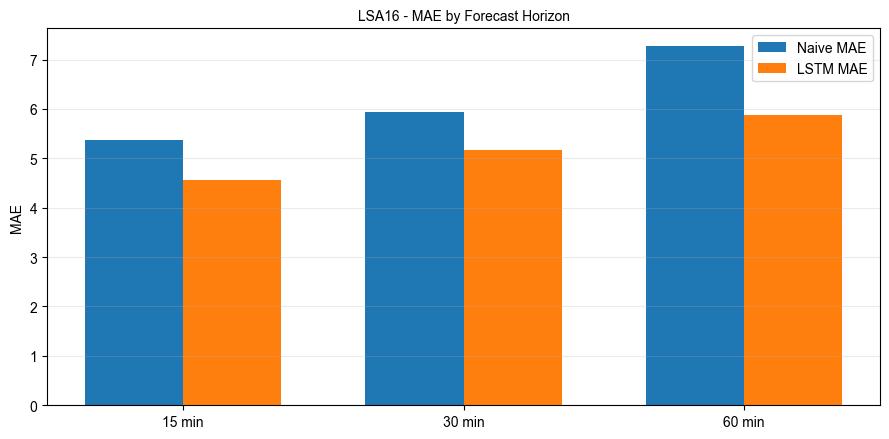

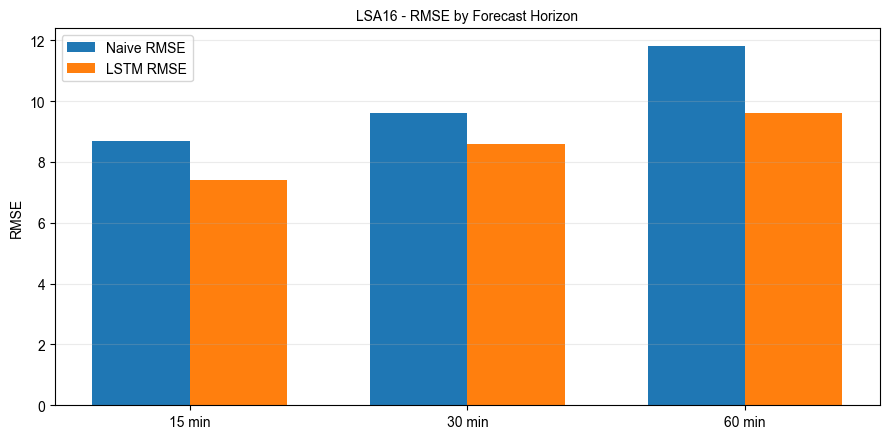

In [17]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import numpy as np

x = np.arange(len(results_df))
labels = [f"{m} min" for m in results_df["horizon_minutes"]]

width = 0.35

# MAE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, results_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, labels)
plt.ylabel("MAE")
plt.title("LSA16 - MAE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, results_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, labels)
plt.ylabel("RMSE")
plt.title("LSA16 - RMSE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The LSA10 results demonstrate that the LSTM model provides clear predictive value over the naive baseline, particularly for longer horizons, suggesting that sequence-based learning is beneficial when short-term persistence becomes less informative.

For LSA10, the multi-horizon forecasting experiment confirms the findings obtained for LSA16. The intersection-specific LSTM model outperforms the naive persistence baseline at all evaluated horizons of 15, 30, and 60 minutes. Although prediction errors increase with longer forecasting horizons for both models, the LSTM consistently achieves lower MAE and RMSE values. The relative improvement over the naive benchmark becomes more pronounced as the horizon increases, indicating that the sequence-based model is particularly beneficial when short-term persistence becomes less informative. Together with the LSA16 results, this suggests that intersection-specific LSTM models trained on longer historical datasets provide a more suitable forecasting framework than a single shared corridor-wide model trained only on the limited